# Razón Estandarizada de Morbilidad

La Razón Estandarizada de Morbilidad (REM) es un indicador epidemiológico que permite comparar la carga de una enfermedad entre diferentes territorios, ajustando por el tamaño de su población. Se obtiene al dividir el número de casos observados en una zona geográfica (en el caso de Colombia sus departamentos) por el número de casos esperados, calculados a partir de la tasa nacional de incidencia. Este indicador facilita identificar áreas con exceso o déficit de morbilidad respecto al promedio nacional, evidenciando territorios donde el riesgo de enfermar es mayor o menor al esperado. En el caso del dengue, la REM resulta útil para reconocer patrones espaciales de transmisión y priorizar regiones que requieren mayores esfuerzos de vigilancia y control vectorial.

$$
REM = \frac{O}{E}
$$

donde:
- O = número de casos observados en la zona,
- E = número de casos esperados según la tasa nacional de incidencia.


In [6]:
# [Configuración] Imports
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# [Configuración] Lectura de archivos

## Archivos CSV de REM
rem_clasico = pd.read_csv(r"REM/REM_Clasico_COL.csv")
rem_grave = pd.read_csv(r"REM/REM_Grave_COL.csv")
rem_periodo_grave = pd.read_csv(r"REM/REM_PERIODO_Grave_COL.csv")
rem_periodo_clasico = pd.read_csv(r"REM/REM_PERIODO_Clasico_COL.csv")

## Archivo shapefile de departamentos
gdf = gpd.read_file("Mapas/Departamento/MGN_ADM_DPTO_POLITICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'dpto_cnmbr': 'departamento'})

In [14]:
# [Funciones] Graficar panel de mapas REM por años

def graficar_panel_rem(df, shp, evento=None):
    """
    Grafica un panel de mapas del REM de dengue en Colombia por años,
    cada uno con su escala individual.
    
    Parámetros:
        df (pd.DataFrame): datos con columnas [departamento, anio, rem].
        shp (gpd.GeoDataFrame): shapefile de Colombia con columna DPTO_CNMBR.
        evento (str, opcional): tipo de evento ("Clásico", "Grave", etc.).
    """

    # === 1. Normalizar nombres ===
    df["departamento"] = df["departamento"].str.upper().str.strip()
    shp["departamento"] = shp["departamento"].str.upper().str.strip()

    # === 2. Lista de años únicos ordenados ===
    anios = sorted(df["año"].unique())

    # === 3. Crear figure y ejes ===
    ncols = 4
    nrows = (len(anios) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))
    axes = axes.flatten()

    for i, anio in enumerate(anios):
        ax = axes[i]
        df_anio = df[df["año"] == anio]
        gdf_anio = shp.merge(df_anio, left_on="departamento", right_on="departamento", how="left")
        gdf_anio["REM"] = gdf_anio["REM"].fillna(0)

        vmin = gdf_anio["REM"].min()
        vmax = gdf_anio["REM"].max()

        # Graficar mapa
        gdf_anio.plot(
            column="REM",
            cmap="Blues",
            linewidth=0.5,
            edgecolor="0.8",
            vmin=vmin, vmax=vmax,
            ax=ax,
            legend=True,
            legend_kwds={"shrink": 0.6, "label": "REM"}
        )

        ax.set_title(str(anio), fontsize=12, fontweight="bold")
        ax.axis("off")

    # Ocultar subplots vacíos
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    # === 4. Título global ===
    titulo = f"REM del dengue {evento or 'general'} en Colombia ({anios[0]}–{anios[-1]})"
    fig.suptitle(titulo, fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    

# [Funciones] Graficar panel de mapas REM por periodos.

def graficar_periodos(df, shp, evento=None):
    """
    Grafica un panel de mapas del REM de dengue en Colombia por años,
    cada uno con su escala individual.
    
    Parámetros:
        df (pd.DataFrame): datos con columnas [departamento, anio, rem].
        shp (gpd.GeoDataFrame): shapefile de Colombia con columna DPTO_CNMBR.
        evento (str, opcional): tipo de evento ("Clásico", "Grave", etc.).
    """

    # === 1. Normalizar nombres ===
    df["departamento"] = df["departamento"].str.upper().str.strip()
    shp["departamento"] = shp["departamento"].str.upper().str.strip()

    # === 2. Lista de años únicos ordenados ===
    anios = sorted(df["periodo"].unique())

    # === 3. Crear figure y ejes ===
    ncols = 3
    nrows = (len(anios) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))
    axes = axes.flatten()

    for i, anio in enumerate(anios):
        ax = axes[i]
        df_anio = df[df["periodo"] == anio]
        gdf_anio = shp.merge(df_anio, left_on="departamento", right_on="departamento", how="left")
        gdf_anio["REM"] = gdf_anio["REM"].fillna(0)

        vmin = gdf_anio["REM"].min()
        vmax = gdf_anio["REM"].max()

        # Graficar mapa
        gdf_anio.plot(
            column="REM",
            cmap="Blues",
            linewidth=0.5,
            edgecolor="0.8",
            vmin=vmin, vmax=vmax,
            ax=ax,
            legend=True,
            legend_kwds={"shrink": 0.6, "label": "REM"}
        )

        ax.set_title(str(anio), fontsize=12, fontweight="bold")
        ax.axis("off")

    # Ocultar subplots vacíos
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    # === 4. Título global ===
    titulo = f"REM del dengue {evento or 'general'} en Colombia ({anios[0]}–{anios[-1]})"
    fig.suptitle(titulo, fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    


## **REM por Año**

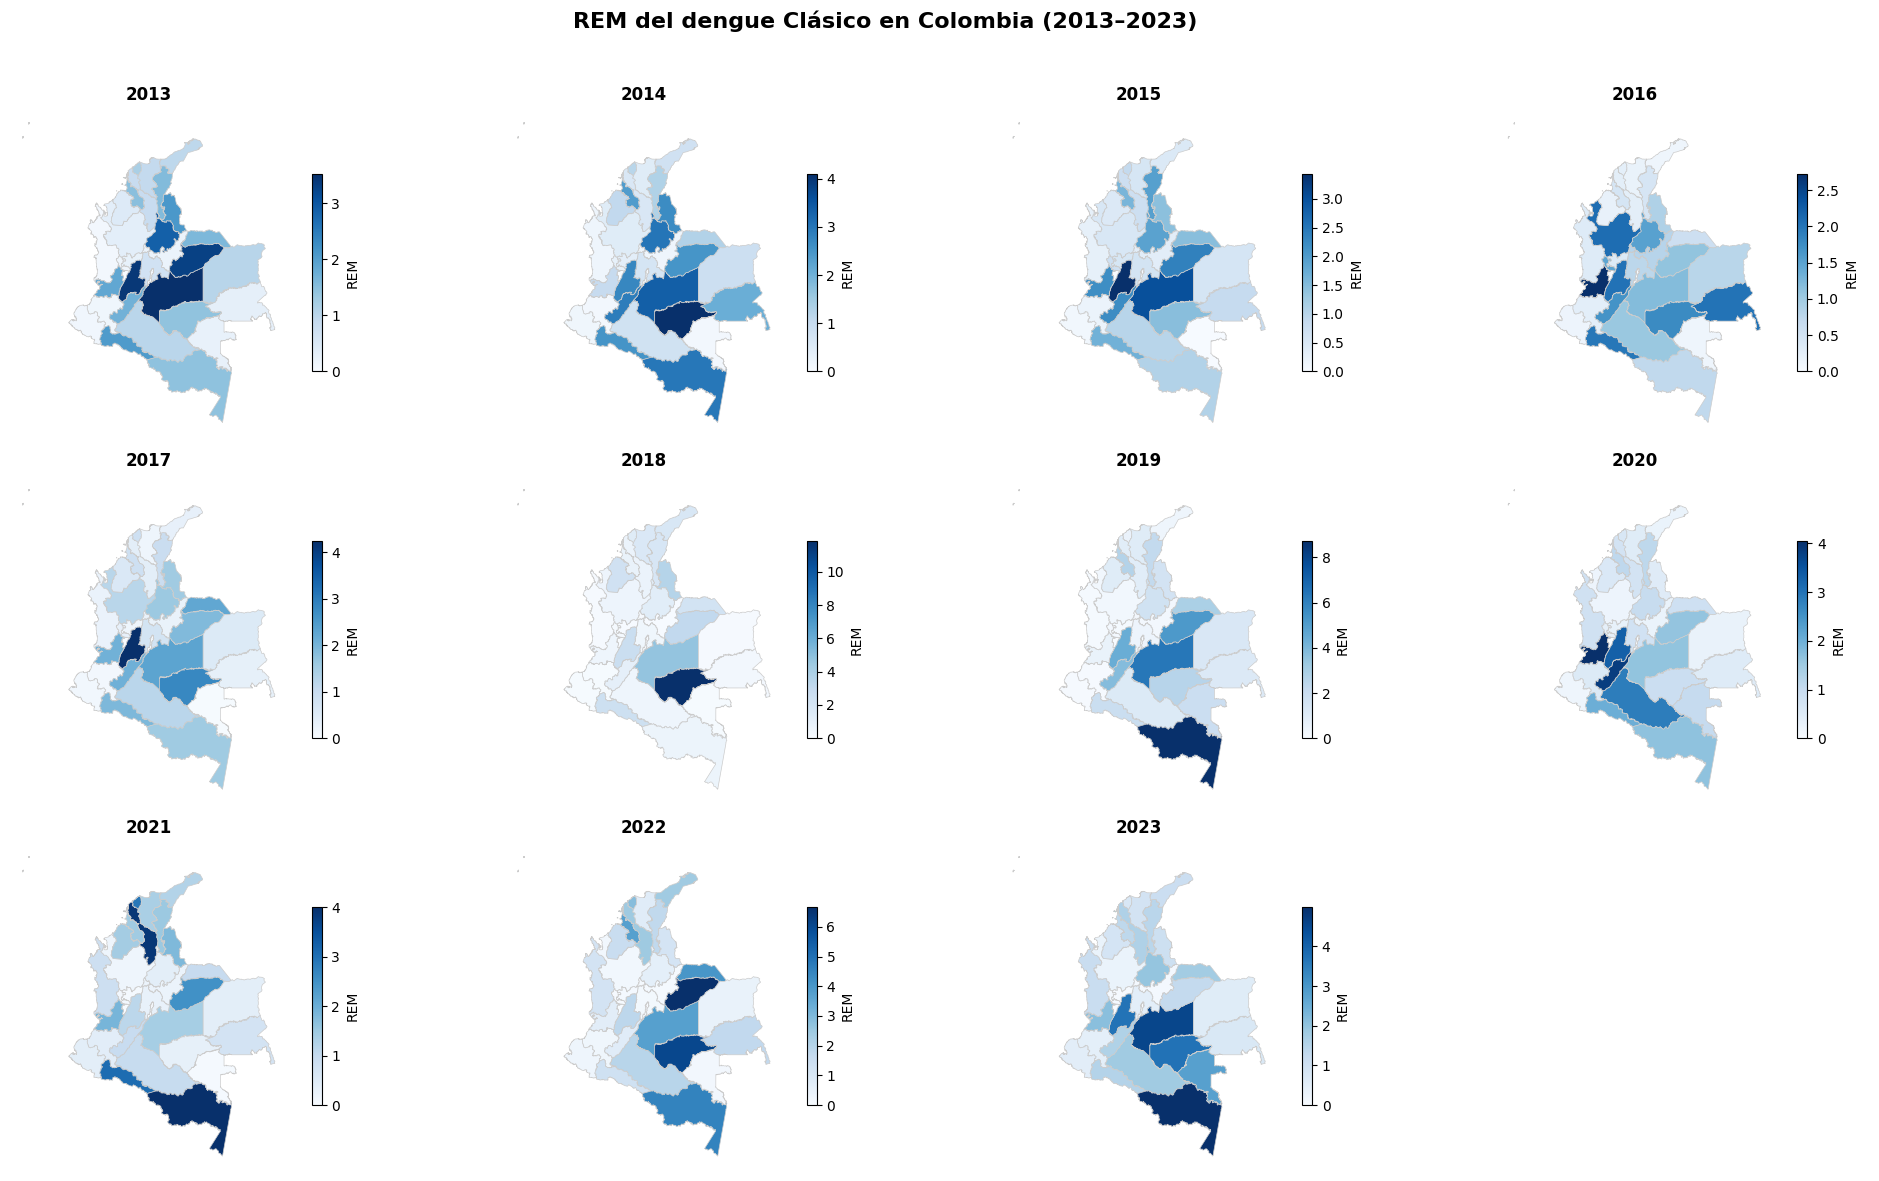

In [8]:
graficar_panel_rem(rem_clasico, gdf, evento="Clásico")

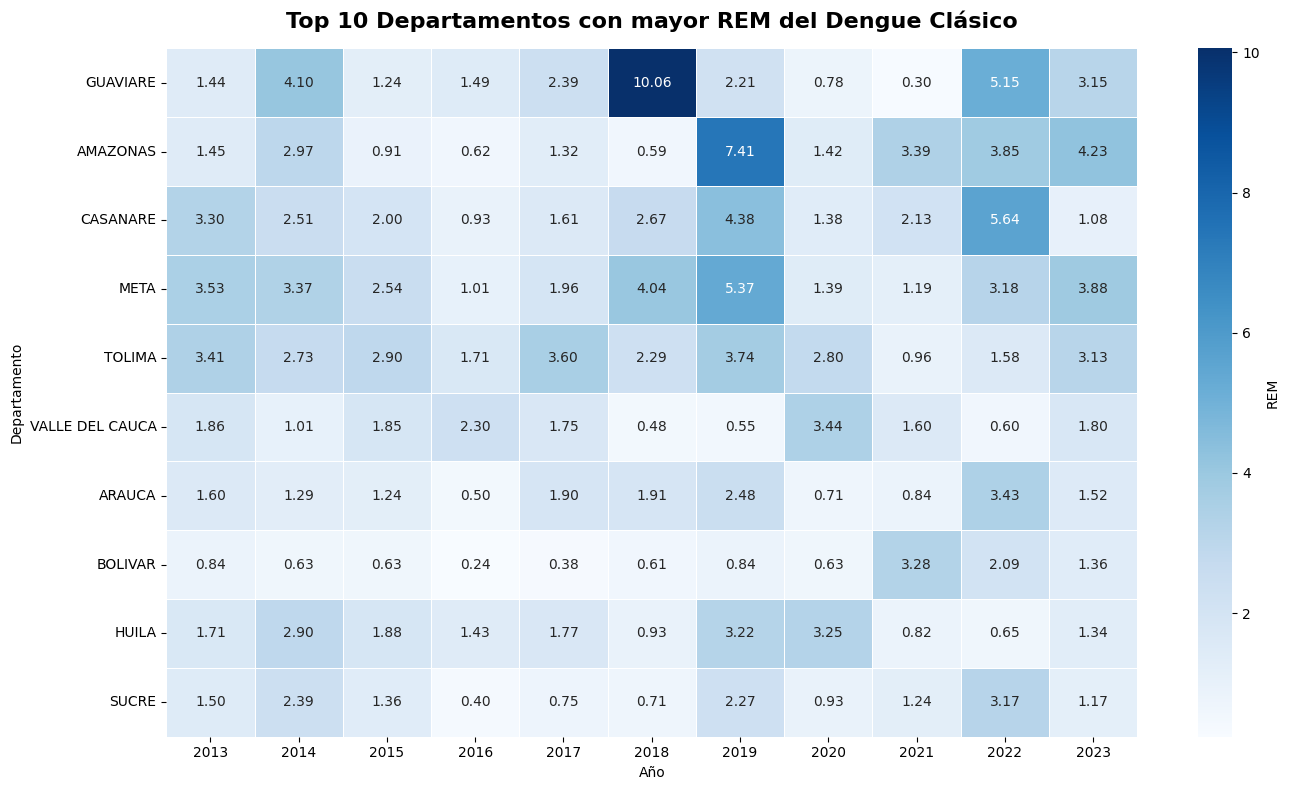

In [ ]:
# === 1. Pivotear ===
tabla_clasico_rem = rem_clasico.pivot(
    index="departamento", 
    columns="anio", 
    values="rem"
).fillna(0)

# === 2. Seleccionar top 10 departamentos con mayores valores de REM ===
top10_departamentos = (
    tabla_clasico_rem.max(axis=1)  # máximo de cada depto en todos los años
    .nlargest(10)                  # los 10 más altos
    .index                         # nombres de los deptos
)
tabla_top10 = tabla_clasico_rem.loc[top10_departamentos]

# === 3. Graficar heatmap ===
plt.figure(figsize=(14, 8))
sns.heatmap(
    tabla_top10,
    cmap="Blues",
    annot=True,
    fmt=".2f",              # <-- mostrar con 2 decimales
    linewidths=0.5,
    cbar_kws={'label': 'REM'}
)

plt.title("Top 10 Departamentos con mayor REM del Dengue Clásico", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()


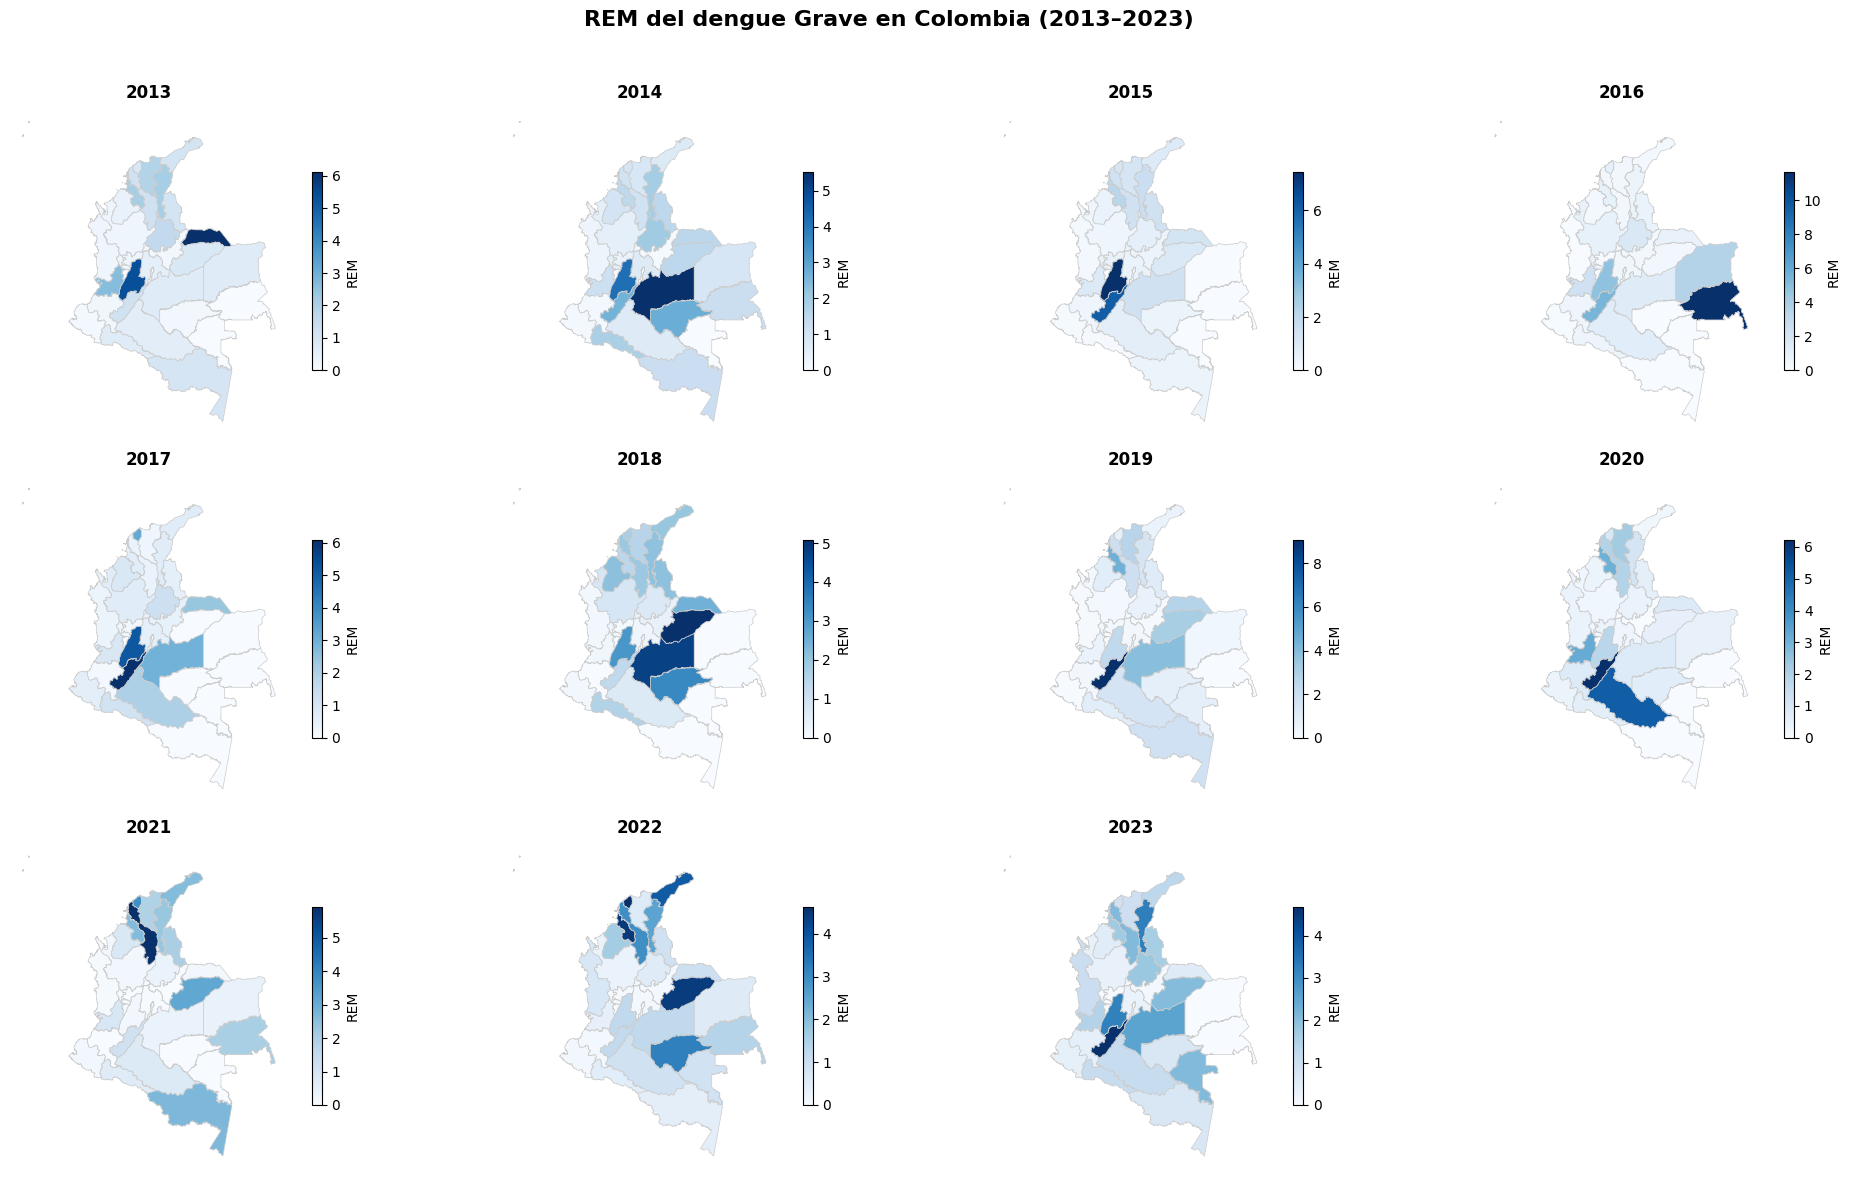

In [9]:
graficar_panel_rem(rem_grave, gdf, evento="Grave")

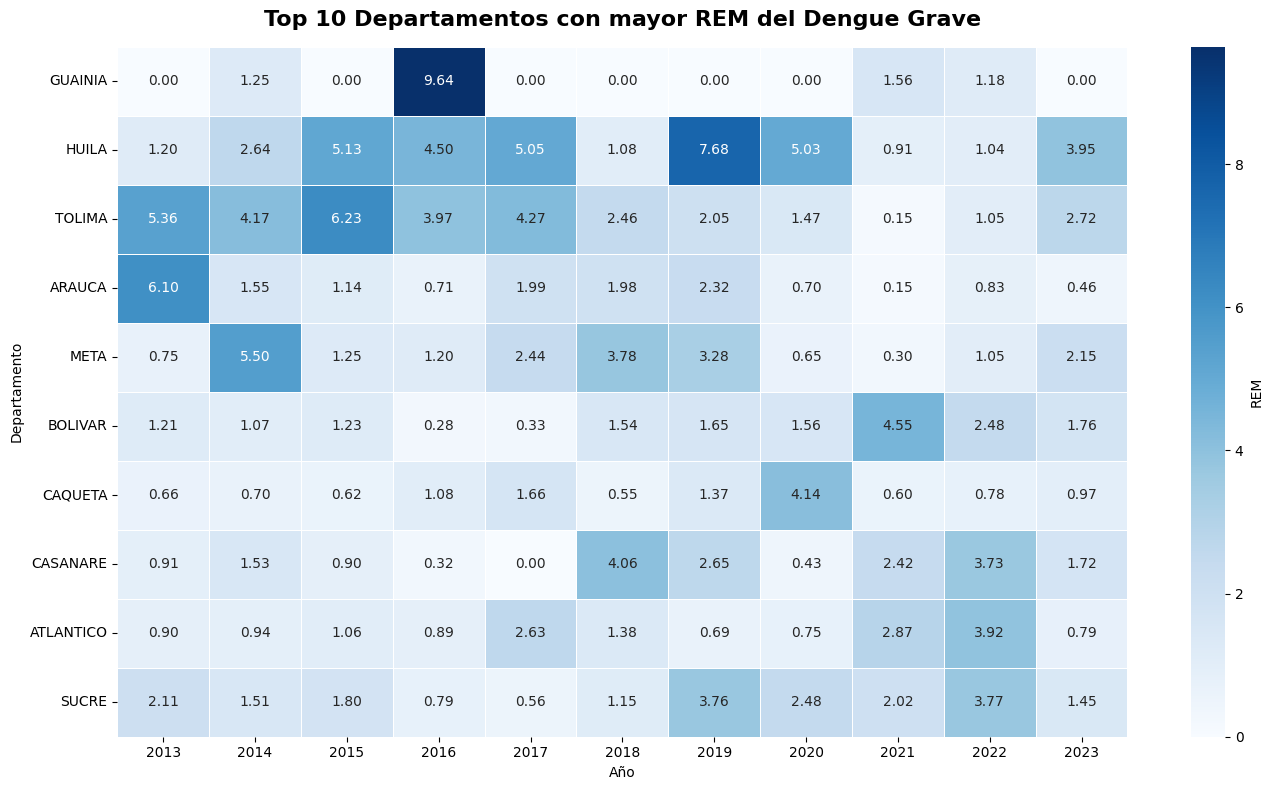

In [ ]:


# === 1. Pivotear ===
tabla_grave_rem = rem_grave.pivot(
    index="departamento", 
    columns="anio", 
    values="rem"
).fillna(0)

# === 2. Seleccionar top 10 departamentos con mayores valores de REM ===
top10_departamentos = (
    tabla_grave_rem.max(axis=1)  # máximo de cada depto en todos los años
    .nlargest(10)                  # los 10 más altos
    .index                         # nombres de los deptos
)
tabla_top10 = tabla_grave_rem.loc[top10_departamentos]

# === 3. Graficar heatmap ===
plt.figure(figsize=(14, 8))
sns.heatmap(
    tabla_top10,
    cmap="Blues",
    annot=True,
    fmt=".2f",              # <-- mostrar con 2 decimales
    linewidths=0.5,
    cbar_kws={'label': 'REM'}
)

plt.title("Top 10 Departamentos con mayor REM del Dengue Grave", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()


## **REM por Periodo**


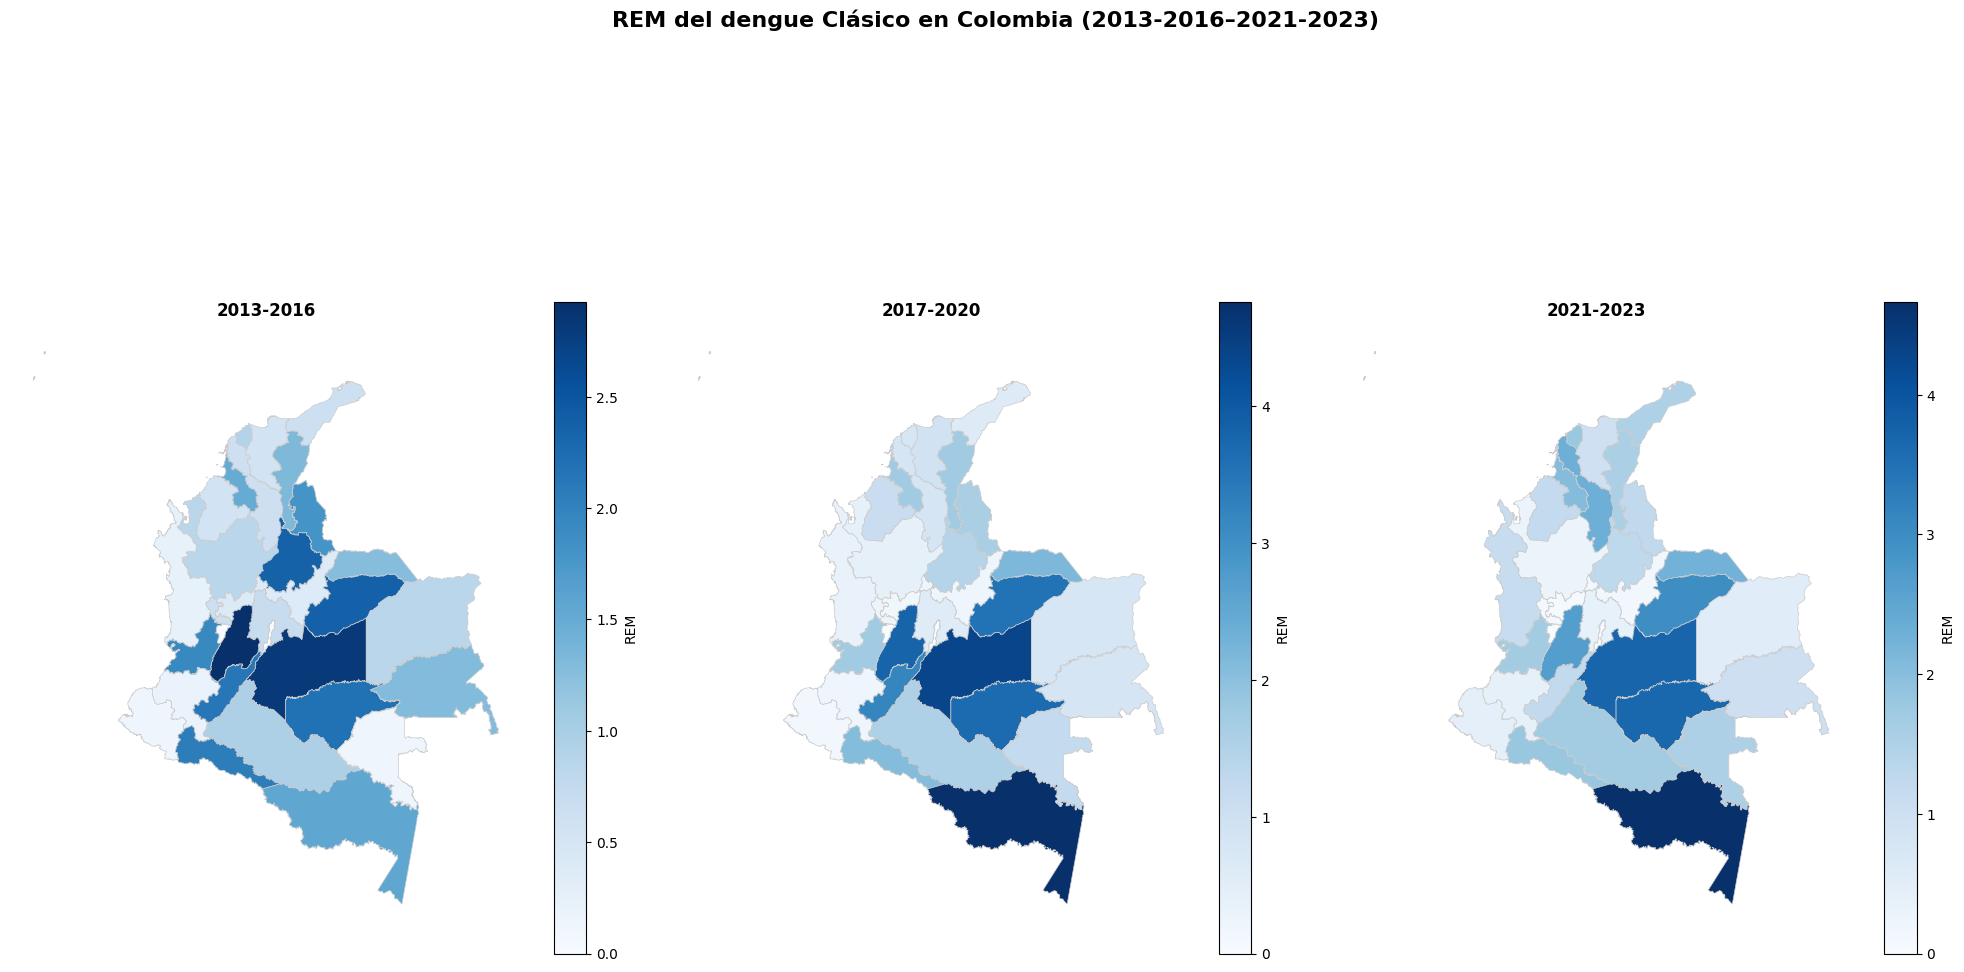

In [13]:
graficar_periodos(rem_periodo_clasico, gdf, evento="Clásico")

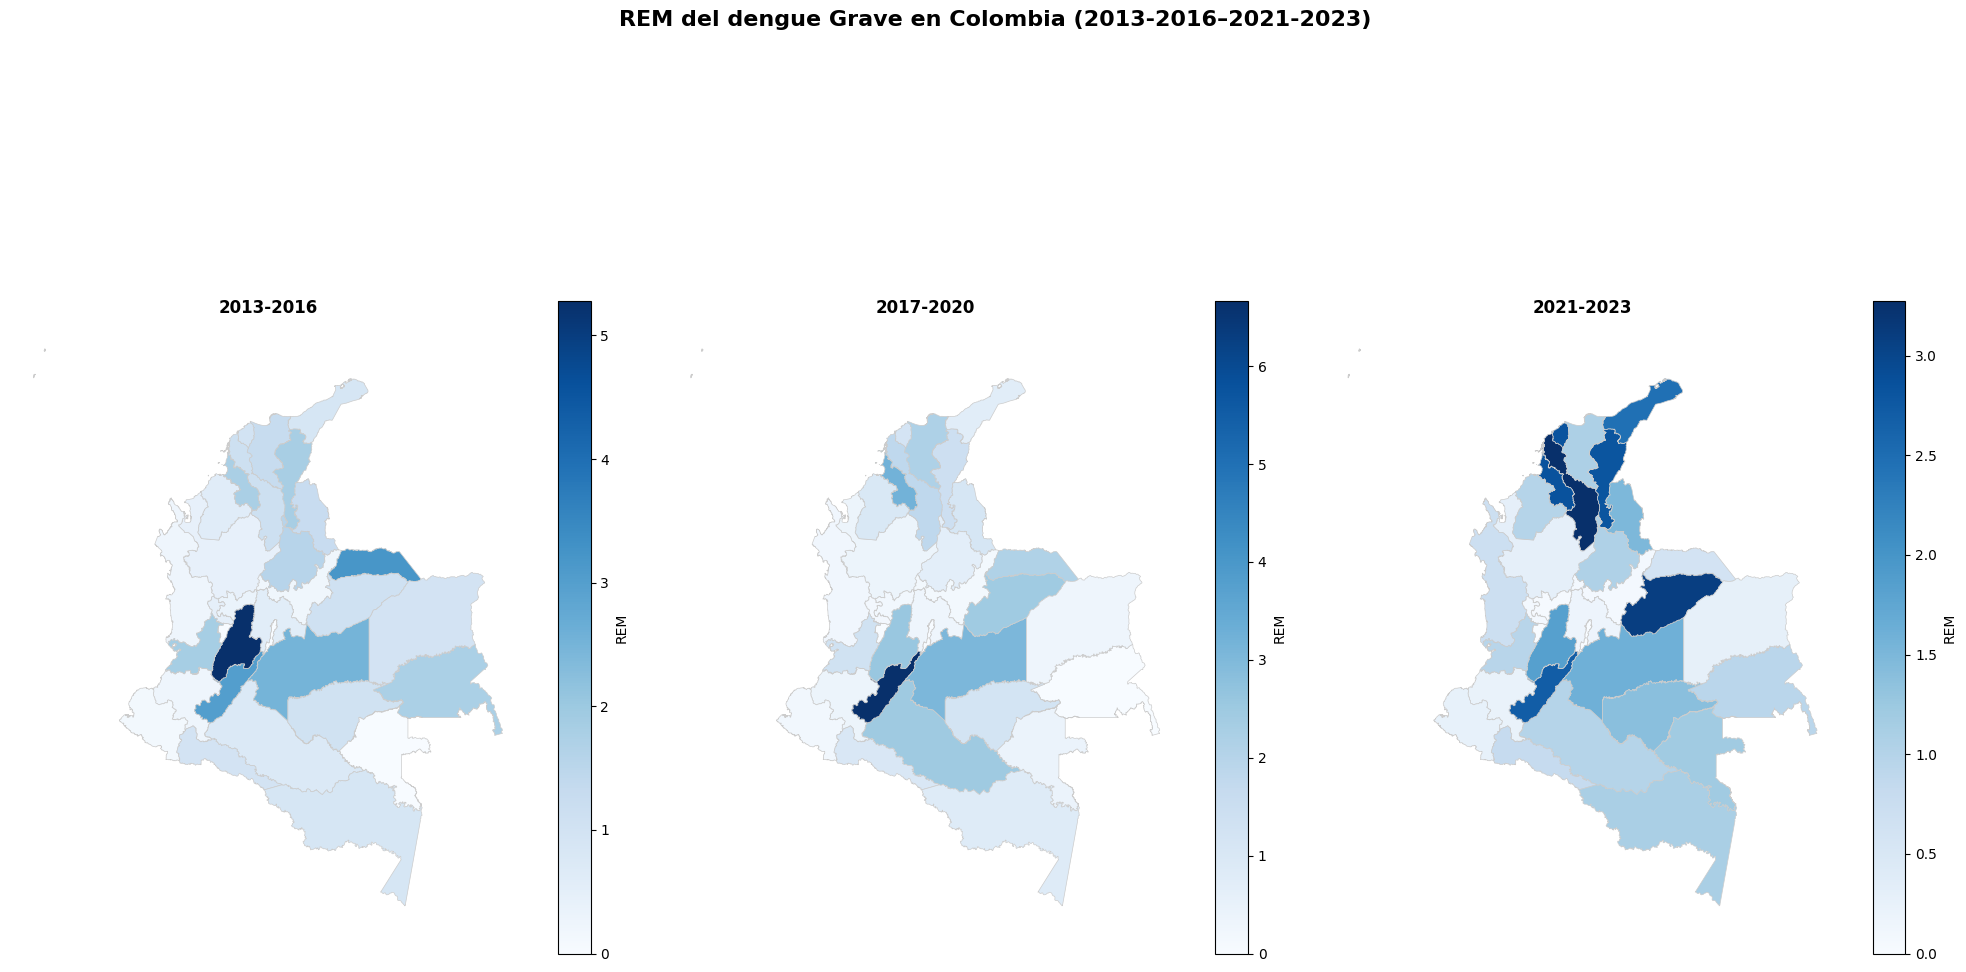

In [12]:

graficar_periodos(rem_periodo_grave, gdf, evento="Grave")